first way to implement subgraph
1. invoke small graph inside a node of big graph

In [16]:
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv

load_dotenv()

True

In [17]:
class subState(TypedDict):
    input_text: str
    translated_text : str

    

In [18]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [19]:

def translate_to_hindi(state : subState) -> subState:
    prompt = f"""translate the following text to hindi : {state['input_text']}

    note: don't add any extra text , only return the translated text"""

    response = llm.invoke(prompt).content

    return {'translated_text':response}

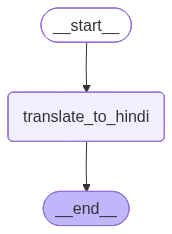

In [ ]:
graph = StateGraph(subState)

graph.add_node("translate_to_hindi",translate_to_hindi)

graph.add_edge(START,"translate_to_hindi")
graph.add_edge("translate_to_hindi",END)

subgraph = graph.compile()

subgraph

In [21]:
# creating big graph 

class BigState(TypedDict):
    input : str
    eng_answer : str
    hindi_answer: str
    


In [22]:
def generate_answer(state: BigState) -> BigState:
    prompt = f"""give the answer for the following question clearly and briefly {state['input']}"""

    response = llm.invoke(prompt).content

    return {'eng_answer':response}

In [23]:
def translation(state : BigState) -> BigState:
    result = subgraph.invoke({"input_text":state['eng_answer']})

    return {"hindi_answer": result['translated_text']}

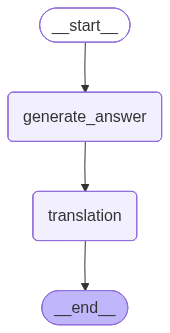

In [24]:
graph = StateGraph(BigState)

graph.add_node("generate_answer",generate_answer)
graph.add_node("translation",translation)

graph.add_edge(START,"generate_answer")
graph.add_edge("generate_answer","translation")
graph.add_edge("translation",END)

Big_graph = graph.compile()
Big_graph

In [25]:
final_state = Big_graph.invoke({"input":"tell me about genai ?what is it ?"})
final_state

{'input': 'tell me about genai ?what is it ?',
 'eng_answer': "I'd be happy to explain GenAI (also known as General Artificial Intelligence).\n\n**What is GenAI?**\n\nGenAI refers to a type of Artificial Intelligence (AI) that possesses the ability to understand, learn, and apply knowledge across a wide range of tasks, much like a human being. It is designed to be a general-purpose intelligence, meaning it can adapt to various situations, learn from experience, and apply its knowledge to solve problems in different domains.\n\n**Key characteristics of GenAI:**\n\n1. **General Knowledge**: GenAI has a broad understanding of the world, including its history, culture, science, and technology.\n2. **Reasoning and Problem-Solving**: GenAI can reason, make decisions, and solve complex problems using its knowledge and experience.\n3. **Learning and Adaptation**: GenAI can learn from data, experiences, and feedback, and adapt to new situations and environments.\n4. **Human-like Intelligence**:

2. add the subgraph as a node in biggraph


In [26]:
class BigState(TypedDict):
    input : str
    eng_answer : str
    hindi_answer: str

In [40]:

def translate_to_hindi(state : BigState) -> BigState:  #it has shared state in this method 
    prompt = f"""translate the following text to hindi : {state['eng_answer']}

    note: don't add any extra text , only return the translated text"""

    response = llm.invoke(prompt).content

    return {'hindi_answer':response}

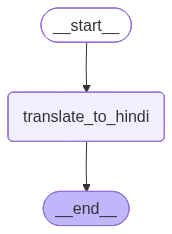

In [41]:
graph = StateGraph(BigState)  # same shared state as big graph

graph.add_node("translate_to_hindi",translate_to_hindi)

graph.add_edge(START,"translate_to_hindi")
graph.add_edge("translate_to_hindi",END)

subgraph = graph.compile()

subgraph

In [42]:
def generate_answer(state: BigState) -> BigState:
    prompt = f"""give the answer for the following question clearly and briefly {state['input']}"""

    response = llm.invoke(prompt).content

    return {'eng_answer':response}

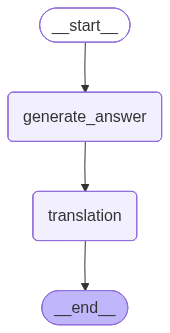

In [43]:
graph = StateGraph(BigState)

graph.add_node("generate_answer",generate_answer)
graph.add_node("translation",subgraph)  # add subgraph as node 

graph.add_edge(START,"generate_answer")
graph.add_edge("generate_answer","translation")
graph.add_edge("translation",END)

Big_graph = graph.compile()
Big_graph

In [44]:
final_state = Big_graph.invoke({"input":"what is ai?"})
final_state

{'input': 'what is ai?',
 'eng_answer': '**Artificial Intelligence (AI)** is the development of computer systems that can perform tasks that typically require human intelligence, such as:\n\n- Learning\n- Problem-solving\n- Reasoning\n- Perception\n- Understanding natural language\n\nIn simpler terms, AI refers to machines that can think, learn, and act like humans.',
 'hindi_answer': '**न्यूरल नेटवर्क (AI)**  मानव इंटेलिजेंस की आवश्यकता वाली कार्यों को करने के लिए कंप्यूटर सिस्टम का विकास है, जैसे:\n\n- सीखना\n- समस्या समाधान\n- तर्क\n- परिचिति\n- प्राकृतिक भाषा को समझना\n\nआसान शब्दों में, AI मशीनों को मशीनें हैं जो वैसे ही सोचना, सीखना और कार्य करना जैसे मानव करता है।'}